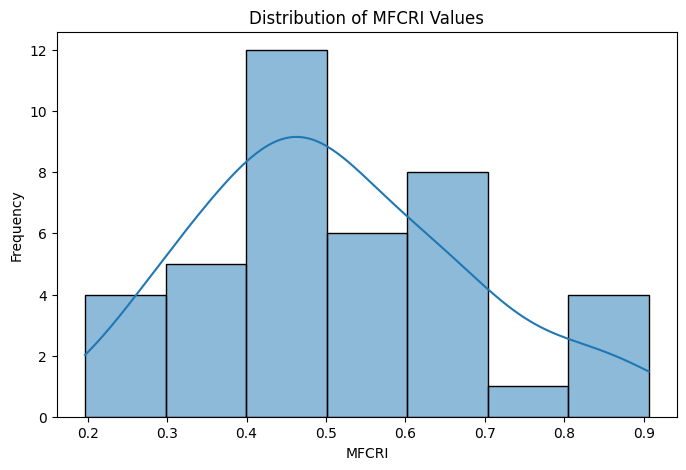

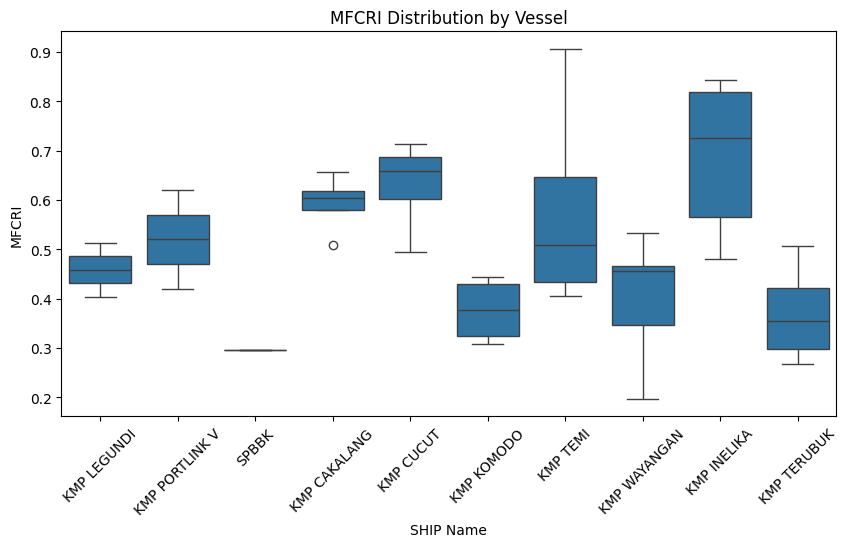

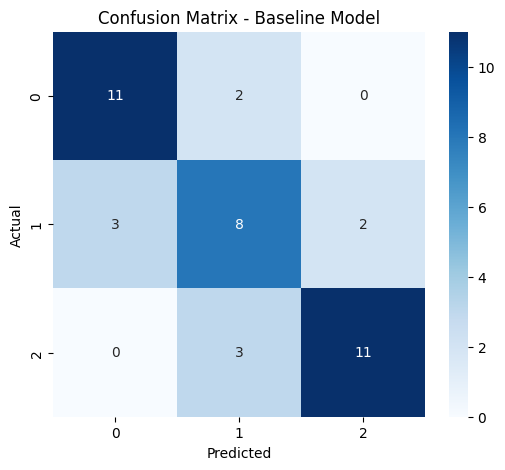

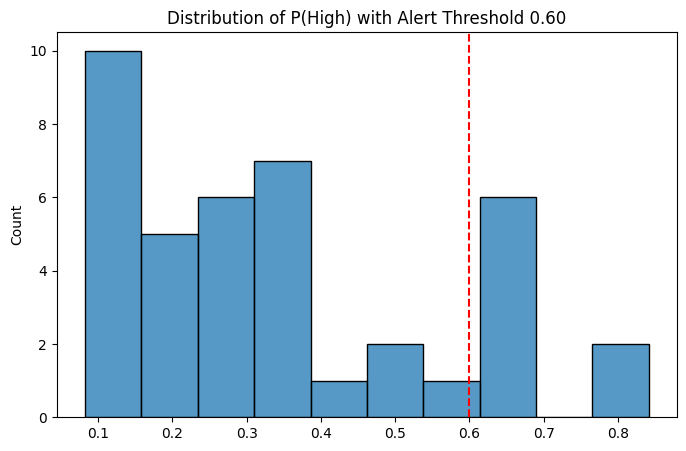

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import CalibratedClassifierCV

# =========================
# Load & Clean Data
# =========================

path = "Dataset_High_Blend_Biodiesel.xlsx"
raw = pd.read_excel(path, sheet_name="DB_MAIN", header=None)

cols = [str(x).strip().replace("\n"," ") if pd.notna(x) else None for x in raw.iloc[0].tolist()]
cols = [re.sub(r"\s+"," ",c) if c else None for c in cols]

df = raw.iloc[3:].copy()
df.columns = cols
df = df[df["Sample Id"].notna()].reset_index(drop=True)

def to_num(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s.startswith("<"):
        try: return float(s[1:]) * 0.5
        except: return np.nan
    if s.startswith(">"):
        s = s[1:]
    s = s.replace(",", "")
    m = re.search(r"[-+]?\d*\.?\d+", s)
    return float(m.group()) if m else np.nan

features = ["TAN","Viscosity @ 40 deg C","Water Content","%FAME"]
for c in features:
    df[c] = df[c].apply(to_num)

df2 = df.dropna(subset=features).copy()

# =========================
# MFCRI Construction
# =========================

def rank_norm(s):
    return s.rank(pct=True)

W = np.clip((df2["Water Content"]-200)/400,0,1)
A = rank_norm(df2["TAN"])
V = rank_norm(df2["Viscosity @ 40 deg C"])
F = rank_norm(df2["%FAME"])

df2["MFCRI"] = 0.35*W + 0.30*A + 0.20*V + 0.15*F

# =========================
# Figure 5 - MFCRI Histogram
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df2["MFCRI"], kde=True)
plt.title("Distribution of MFCRI Values")
plt.xlabel("MFCRI")
plt.ylabel("Frequency")
plt.show()

# =========================
# Figure 6 - MFCRI by Vessel
# =========================
plt.figure(figsize=(10,5))
sns.boxplot(x="SHIP Name", y="MFCRI", data=df2)
plt.xticks(rotation=45)
plt.title("MFCRI Distribution by Vessel")
plt.show()

# =========================
# Risk Classes
# =========================
p33 = df2["MFCRI"].quantile(0.333)
p66 = df2["MFCRI"].quantile(0.666)

def risk_class(x):
    if x <= p33: return 0
    if x <= p66: return 1
    return 2

df2["RiskClass"] = df2["MFCRI"].apply(risk_class)

# =========================
# RandomForest Model
# =========================

X = df2[features]
y = df2["RiskClass"]
groups = df2["SHIP Name"]

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=500,
                                  class_weight="balanced",
                                  random_state=42))
])

clf = CalibratedClassifierCV(rf, method="sigmoid", cv=3)

cv = GroupKFold(n_splits=5)

y_pred = np.zeros(len(y))
y_prob = np.zeros((len(y),3))

for tr, te in cv.split(X,y,groups):
    clf.fit(X.iloc[tr], y.iloc[tr])
    y_pred[te] = clf.predict(X.iloc[te])
    y_prob[te] = clf.predict_proba(X.iloc[te])

# =========================
# Confusion Matrix Plot
# =========================
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# Probability Histogram
# =========================
p_high = y_prob[:,2]

plt.figure(figsize=(8,5))
sns.histplot(p_high, bins=10)
plt.axvline(0.6, color='red', linestyle='--')
plt.title("Distribution of P(High) with Alert Threshold 0.60")
plt.show()

                        Mean  StdDev     Min      Max  %>Limit
TAN                     0.18    0.10    0.03     0.49      0.0
Viscosity @ 40 deg C    3.63    0.21    3.27     4.18    100.0
Water Content         432.48  183.23  236.00  1183.00      0.0
%FAME                  34.76    1.61   30.38    36.86    100.0


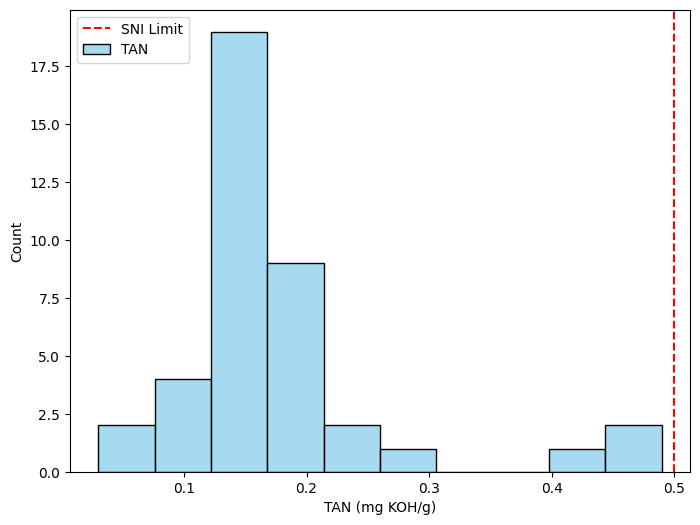

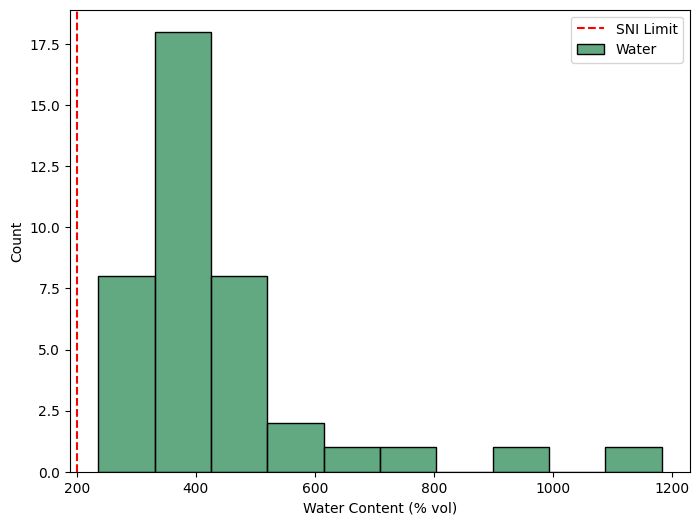

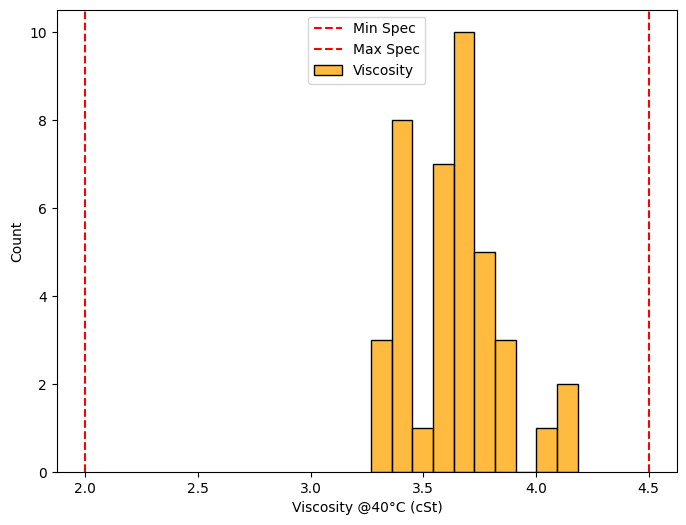

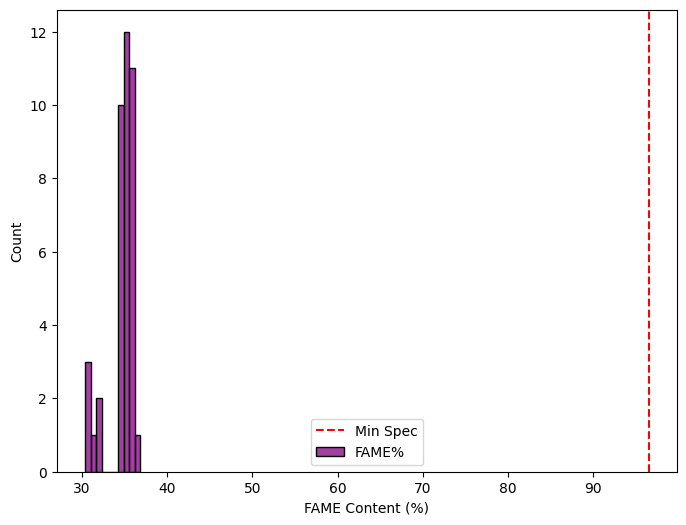

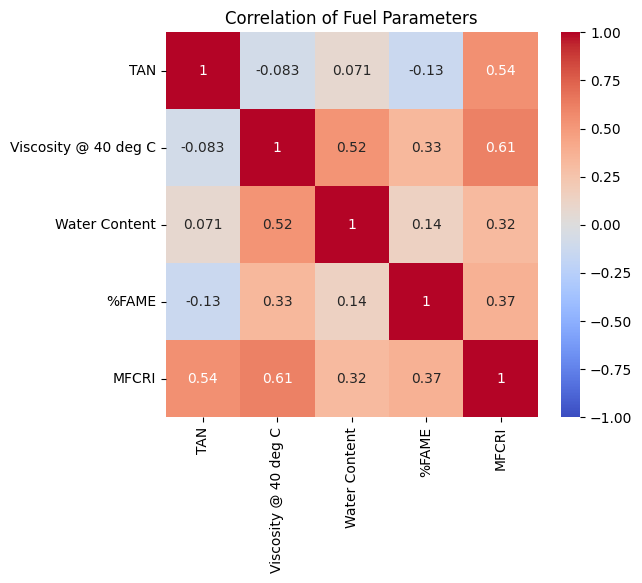

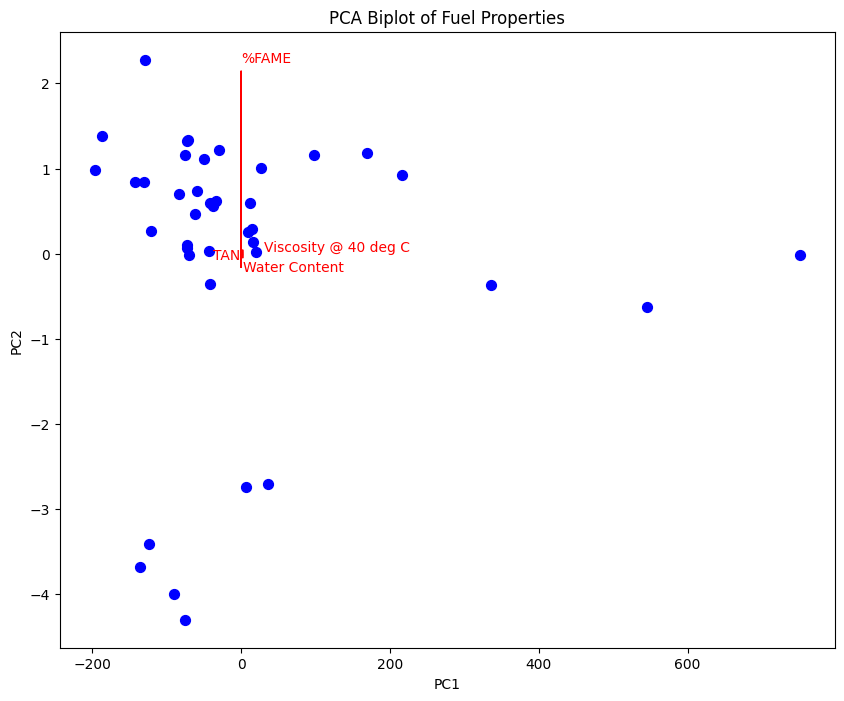

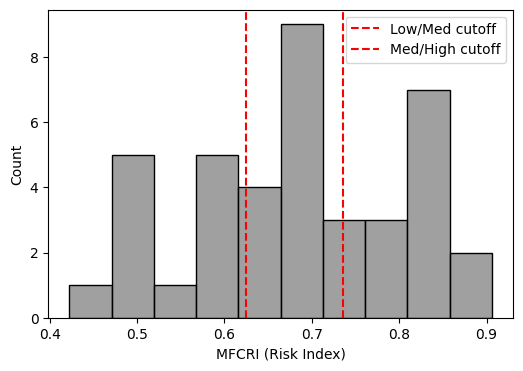

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Added for cleaning column names
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve

# =========================
# Load & Clean Data (Replicating steps from earlier cells)
# =========================
path = "Dataset_High_Blend_Biodiesel.xlsx"
raw = pd.read_excel(path, sheet_name="DB_MAIN", header=None)

# header row 0, unit rows 1-2, data start row 3
cols = [str(x).strip().replace("\n"," ") if pd.notna(x) else None for x in raw.iloc[0].tolist()]
cols = [re.sub(r"\s+"," ",c) if c else None for c in cols]

df = raw.iloc[3:].copy()
df.columns = cols
df = df[df["Sample Id"].notna()].reset_index(drop=True)

def to_num(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s.startswith("<"):
        try: return float(s[1:]) * 0.5
        except: return np.nan
    if s.startswith(">"):
        s = s[1:]
    s = s.replace(",", "")
    m = re.search(r"[-+]?\d*\.?\d+", s)
    return float(m.group()) if m else np.nan

# Define the feature columns based on actual names
features = ["TAN","Viscosity @ 40 deg C","Water Content","%FAME"]
for c in features:
    df[c] = df[c].apply(to_num)

# Ensure all features are numeric by dropping rows with NaNs in these columns for the calculations below
df = df.dropna(subset=features).copy() # Use df, not df2, since this cell reinitializes it

# -- Figure 7: MFCRI Distribution --
# Calculate MFCRI *before* using it in correlation heatmap
df['MFCRI'] = 0.35*pd.Series(np.clip((df['Water Content']-0.2)/0.4,0,1)) \
             + 0.30*df['TAN'].rank(pct=True) \
             + 0.20*df['Viscosity @ 40 deg C'].rank(pct=True) \
             + 0.15*df['%FAME'].rank(pct=True)

# -- Table 3: Descriptive Stats --
stats = df[features].agg(['mean','std','min','max'])
# Compute %out-of-spec (assuming SNI limits: TAN<=0.50, Water<=0.10, Viscosity 2.0-4.5 cSt, FAME>=96.5)
limits = {
    'TAN':0.50,
    'Water Content':0.10,
    'Viscosity @ 40 deg C_min':2.0,
    'Viscosity @ 40 deg C_max':4.5,
    '%FAME_min':96.5
}
outspec = {
    'TAN': 100*np.mean(df['TAN']>limits['TAN']),
    'Water Content': 100*np.mean(df['Water Content']>limits['Water Content']),
    'Viscosity @ 40 deg C': 100*(np.mean(df['Viscosity @ 40 deg C']<limits['Viscosity @ 40 deg C_min']) + \
                                   np.mean(df['Viscosity @ 40 deg C']>limits['Viscosity @ 40 deg C_max'])),
    '%FAME':100*np.mean(df['%FAME']<limits['%FAME_min'])
}
table3 = pd.DataFrame({
    'Mean': stats.loc['mean'],
    'StdDev': stats.loc['std'],
    'Min': stats.loc['min'],
    'Max': stats.loc['max'],
    '%>Limit': [outspec['TAN'], outspec['Water Content'], outspec['Viscosity @ 40 deg C'], outspec['%FAME']]
})
print(table3.round(2))

# -- Figure 4: Parameter Distributions --
plt.figure(figsize=(8,6))
sns.histplot(df['TAN'], color='skyblue', label='TAN', kde=False, bins=10)
plt.axvline(0.50, color='red', linestyle='--', label='SNI Limit')
plt.xlabel('TAN (mg KOH/g)'); plt.legend()
plt.savefig('fig_TAN_dist.png')

plt.figure(figsize=(8,6))
sns.histplot(df['Water Content'], color='seagreen', label='Water', kde=False, bins=10)
plt.axvline(200, color='red', linestyle='--', label='SNI Limit')
plt.xlabel('Water Content (% vol)'); plt.legend()
plt.savefig('fig_Water_dist.png')

plt.figure(figsize=(8,6))
sns.histplot(df['Viscosity @ 40 deg C'], color='orange', label='Viscosity', kde=False, bins=10)
plt.axvline(2.0, color='red', linestyle='--', label='Min Spec')
plt.axvline(4.5, color='red', linestyle='--', label='Max Spec')
plt.xlabel('Viscosity @40°C (cSt)'); plt.legend()
plt.savefig('fig_Visc_dist.png')

plt.figure(figsize=(8,6))
sns.histplot(df['%FAME'], color='purple', label='FAME%', kde=False, bins=10)
plt.axvline(96.5, color='red', linestyle='--', label='Min Spec')
plt.xlabel('FAME Content (%)'); plt.legend()
plt.savefig('fig_FAME_dist.png')

# -- Figure 5: Correlation Heatmap --
features1 = ["TAN","Viscosity @ 40 deg C","Water Content","%FAME","MFCRI"]
corr = df[features1].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Fuel Parameters')
plt.savefig('fig_correlation_heatmap.png')

# -- Figure 6: PCA Biplot --
X = df[features].values
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)
plt.figure(figsize=(10,8))
plt.scatter(pcs[:,0], pcs[:,1], c='blue', s=50)
for i, param in enumerate(features):
    x_offset = 0
    y_offset = 0
    # Adjust offsets for problematic labels to prevent overlap
    if param == '%FAME':
        x_offset = 0.1 # Shift right
        y_offset = 0.05 # Shift up slightly
    elif param == 'Viscosity @ 40 deg C':
        x_offset = 30.5 # Shift left
        y_offset = -0.05 # Shift down slightly
    elif param == 'Water Content':
        x_offset = 0.05 # Shift right slightly
        y_offset = -0.2 # Shift down
    elif param == 'TAN':
        x_offset = -38.05 # Shift right slightly
        y_offset = -0.05 # Shift down

    plt.arrow(0, 0, pca.components_[0,i]*2, pca.components_[1,i]*2,
              color='red', width=0.01, head_width=0.1)
    plt.text(pca.components_[0,i]*2.2 + x_offset, pca.components_[1,i]*2.2 + y_offset, param, color='red')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA Biplot of Fuel Properties')
plt.savefig('fig_PCA_biplot.png')

plt.figure(figsize=(6,4))
sns.histplot(df['MFCRI'], color='gray', bins=10)
plt.axvline(df['MFCRI'].quantile(0.33), color='red', linestyle='--', label='Low/Med cutoff')
plt.axvline(df['MFCRI'].quantile(0.66), color='red', linestyle='--', label='Med/High cutoff')
plt.xlabel('MFCRI (Risk Index)'); plt.legend()
plt.savefig('fig_MFCRI_histogram.png')
